In [1]:
import torch
import numpy as np
import torch.nn as nn
import lattice_symmetries as ls
from utils import make_unpacked_configurations
import itertools
from sympy.combinatorics import Permutation
from math import factorial
from heisenberg_hamiltonians import HeisenbergJ1J2
from spin_lattices import SquareLattice1Diag, TriangleLattice, KagomeLattice
from loguru import logger
from scipy.optimize import minimize
from hashlib import md5
from pathlib import Path
import pandas as pd
import seaborn as sns
from slater_determinant import configurations_to_tensors, SlaterDeterminant

2023-04-19 20:37:09.861 | DEBUG    | lattice_symmetries:__init__:49 - Initializing Haskell runtime...
2023-04-19 20:37:09.866 | DEBUG    | lattice_symmetries:__init__:51 - Initializing Chapel runtime...
[Debug]   [2023-04-19 20:37:09.919 | DEBUG    | lattice_symmetries:__init__:53 - Setting Python exception handler...
LOCALE0]   Initializing chpl_kernels ...
set_python_exception_handler ...


In [ ]:

def torch_hash(x):
    if isinstance(x, torch.Tensor):
        x = x.detach().numpy()
    return md5(x.tobytes()).hexdigest() + str(x.shape) + str(x.dtype)


In [4]:
from determinant_2023_04_07 import SlaterDeterminant as SlaterDeterminantReference


In [69]:
lattice = KagomeLattice(2, 3)
system = HeisenbergJ1J2(lattice, J1=1, J2=1, use_symmetries=False, spin_inversion=None, ground_state_cache_dir=Path("groundstates"))
det = SlaterDeterminant(system.basis)
# det_ref = SlaterDeterminantReference(system.number_spins)
# det_ref.f = nn.Parameter(det.f.detach().clone())

2023-04-17 15:56:15.748 | DEBUG    | heisenberg_hamiltonians:__init__:448 - number_spins=18
2023-04-17 15:56:15.750 | DEBUG    | heisenberg_hamiltonians:__init__:458 - Symmetry group contains 0 elements
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
2023-04-17 15:56:15.762 | DEBUG    | heisenberg_hamiltonians:__init__:467 - Hilbert space dimension is 48620
2023-04-17 15:56:15.785 | DEBUG    | __main__:__init__:11 - Finding signs...
2023-04-17 15:56:21.357 | DEBUG    | __main__:__init__:15 - Ready


In [6]:
# ref = det_ref(configurations_to_tensors(make_unpacked_configurations(system.basis.states, number_spins=system.number_spins).astype('int64')))

In [7]:
# assert (det(torch.arange(len(system.basis.states)).long()) == ref).all().item()

In [21]:
system.get_eigenstates(1)

2023-04-17 14:07:57.622 | DEBUG    | heisenberg_hamiltonians:_find_cached_eigenstate:60 - Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x3-1.0-1.0-False-None-1.pickle
2023-04-17 14:07:57.667 | DEBUG    | heisenberg_hamiltonians:get_eigenstates:107 - Ground state energy is -32.1930830942


(array([-32.19308309]),
 array([[ 4.67734071e-06],
        [ 4.05907513e-05],
        [-1.98695729e-05],
        ...,
        [ 1.98695729e-05],
        [-4.05907513e-05],
        [-4.67734071e-06]]))

In [ ]:
# rows = []
# log = []
for eps_train in [0.025, 0.05 , 0.1  , 0.3]:
    gs_numpy = system.get_eigenstates(1)[1][:, 0]
    # print(f"{gs_numpy.sum()=}")
    ground_state = torch.from_numpy(gs_numpy)
    train_set_numpy = np.random.choice(
        len(system.basis.states),
        int(eps_train * len(system.basis.states)),
        replace=False,
        p=ground_state**2,
    )

    train_set = torch.from_numpy(train_set_numpy)
    test_set = torch.from_numpy(np.setdiff1d(np.arange(len(system.basis.states)), train_set_numpy))

    target = (ground_state[train_set] > 0).double()
    number_spins = system.number_spins

    def compute_det(f, x=None):
        if x is None:
            x = train_set
        if not isinstance(f, torch.Tensor):
            f = torch.from_numpy(f)
        with torch.no_grad():
            det.f.copy_(f.reshape((system.number_spins, system.number_spins)))
        # print(f"{torch_hash(f)=}")
        return det(x)

    def loss_fn(f: torch.Tensor) -> torch.Tensor:
        det_output = compute_det(f)
        # print(f"{torch_hash(det_output)=}")
        probs = torch.sigmoid(det_output)
        # print(f"{torch_hash(probs)=}")
        # print(f"{torch_hash(target)=}")
        # loss = torch.nn.functional.binary_cross_entropy(probs, target, reduction="none")
        # loss = torch.dot(loss, ground_state[train_set] ** 2)
        
        loss = torch.nn.functional.binary_cross_entropy(probs, target)

        # overlap = torch.dot(ground_state, signs * torch.abs(ground_state)) ** 2
        # assert overlap <= 1
        # return 1 - overlap
        return loss

    @torch.no_grad()
    def loss_fn_no_grad(f):
        value = loss_fn(f).item()
        # print(f"{torch_hash(f)=}, {md5(repr(value).encode('utf8')).hexdigest()=}")
        return value

    def grad_fn(f):
        p = nn.Parameter(torch.from_numpy(f).reshape((system.number_spins, system.number_spins)))
        if det.f.grad is not None:
            det.f.grad = None
        loss = loss_fn(p)
        loss.backward()
        grad = det.f.grad.numpy().reshape(-1)
        return grad

    def sign_overlap(ground_state, predict_signs):
        probs = ground_state**2
        return torch.dot(ground_state, predict_signs * torch.abs(ground_state)) / probs.sum()

    
    

    logger.debug("Starting minimize")
    np.random.seed(1)
    for i in range(5):
        @torch.no_grad()
        def callback_fn(x, f=None, context=None):
            # overlap_train = torch.dot(ground_state[train_set], torch.sign(compute_det(x)) * torch.abs(ground_state[train_set]))
            # overlap_test = torch.dot(ground_state[test_set], torch.sign(compute_det(x, x=test_set)) * torch.abs(ground_state[test_set]))
            overlap_train = sign_overlap(ground_state[train_set], torch.sign(compute_det(x)))
            overlap_test = sign_overlap(ground_state[test_set], torch.sign(compute_det(x, x=test_set)))
            # print(ground_state[train_set].sum())
            # print(f"{torch_hash(x)=}, {torch_hash(signs)=}, {torch_hash(ground_state[train_set])=}, {torch_hash(overlap)=}")
            log.append(
                {
                    "trial": i,
                    "eps_train": eps_train,
                    "train_set_size": len(train_set),
                    "overlap_train": overlap_train.item(),
                    "overlap_test": overlap_test.item(),
                }
            )
            print(log[-1])

            return

        x0 = 1 - 2 * np.random.rand(system.number_spins**2)
        res = minimize(
            fun=loss_fn_no_grad,
            x0=x0,
            method="BFGS",
            jac=grad_fn,
            options={"maxiter": 1000},
            callback=callback_fn,
        )
        print(res)
        rows.append(
            {
                "trial": i,
                "eps_train": eps_train,
                "train_set_size": len(train_set),
                "minimize_res": res,
                "overlap_train": sign_overlap(
                    ground_state[train_set], torch.sign(compute_det(res.x))
                ),
                "overlap_test": sign_overlap(
                    ground_state[test_set], torch.sign(compute_det(res.x, x=test_set))
                ),
            }
        )


In [85]:
df = pd.DataFrame(rows).assign(
    overlap_train=lambda df: df["overlap_train"].apply(lambda x: x.item()),
    overlap_test=lambda df: df["overlap_test"].apply(lambda x: x.item()),
)


/tmp/ipykernel_11862/1960509837.py:1: UserWarning: 
The markers list has fewer values (1) than needed (2) and will cycle, which may produce an uninterpretable plot.
  sns.relplot(


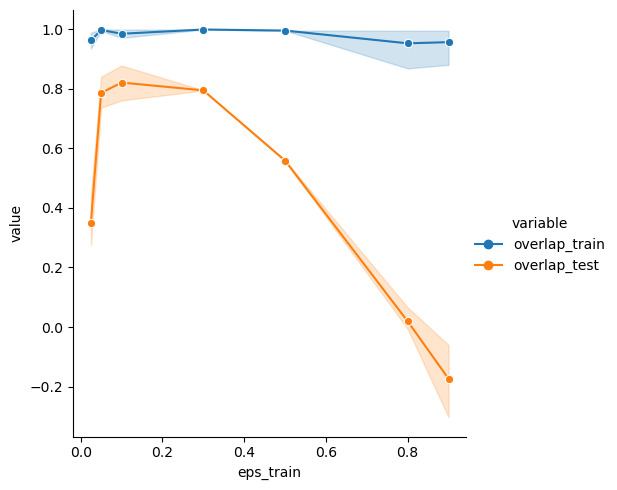

In [87]:
sns.relplot(
    data=df.melt(id_vars=["eps_train", "trial"], value_vars=["overlap_train", "overlap_test"]),
    x="eps_train",
    y="value",
    hue="variable",
    kind="line",
    style='variable',
    markers=['o'],
    dashes=False
)


/tmp/ipykernel_11862/1960509837.py:1: UserWarning: 
The markers list has fewer values (1) than needed (2) and will cycle, which may produce an uninterpretable plot.
  sns.relplot(


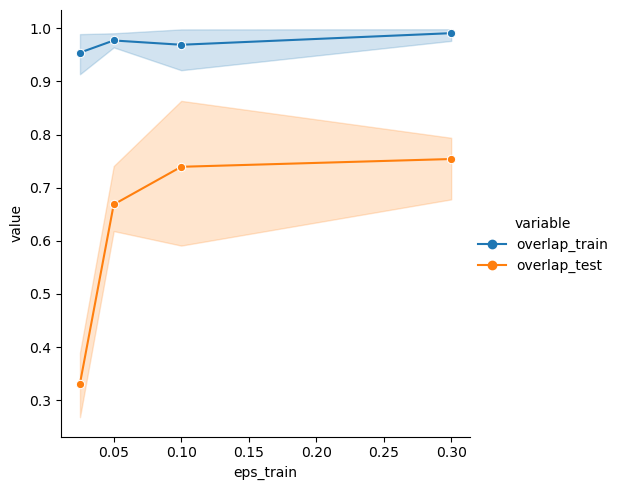

In [57]:
sns.relplot(
    data=df.melt(id_vars=["eps_train", "trial"], value_vars=["overlap_train", "overlap_test"]),
    x="eps_train",
    y="value",
    hue="variable",
    kind="line",
    style='variable',
    markers=['o'],
    dashes=False
)


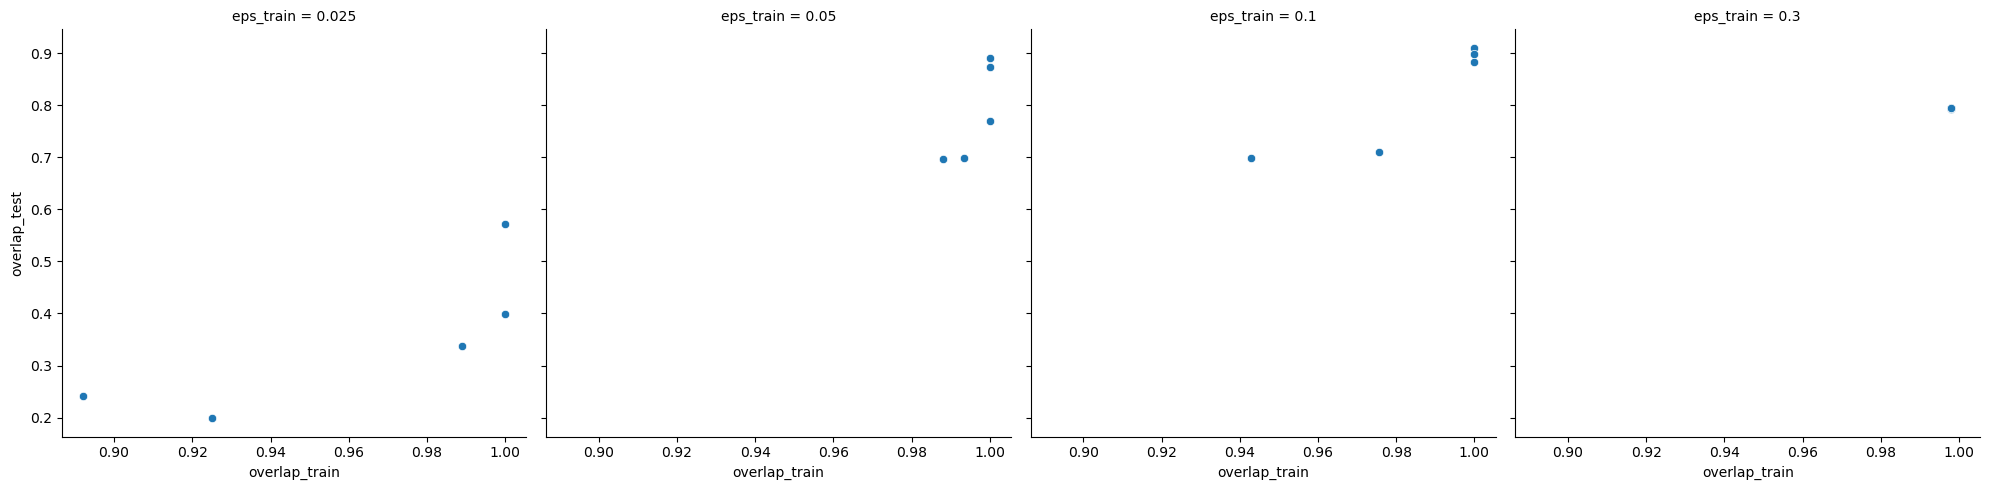

In [67]:
sns.relplot(data=df, x="overlap_train", y="overlap_test", col='eps_train')

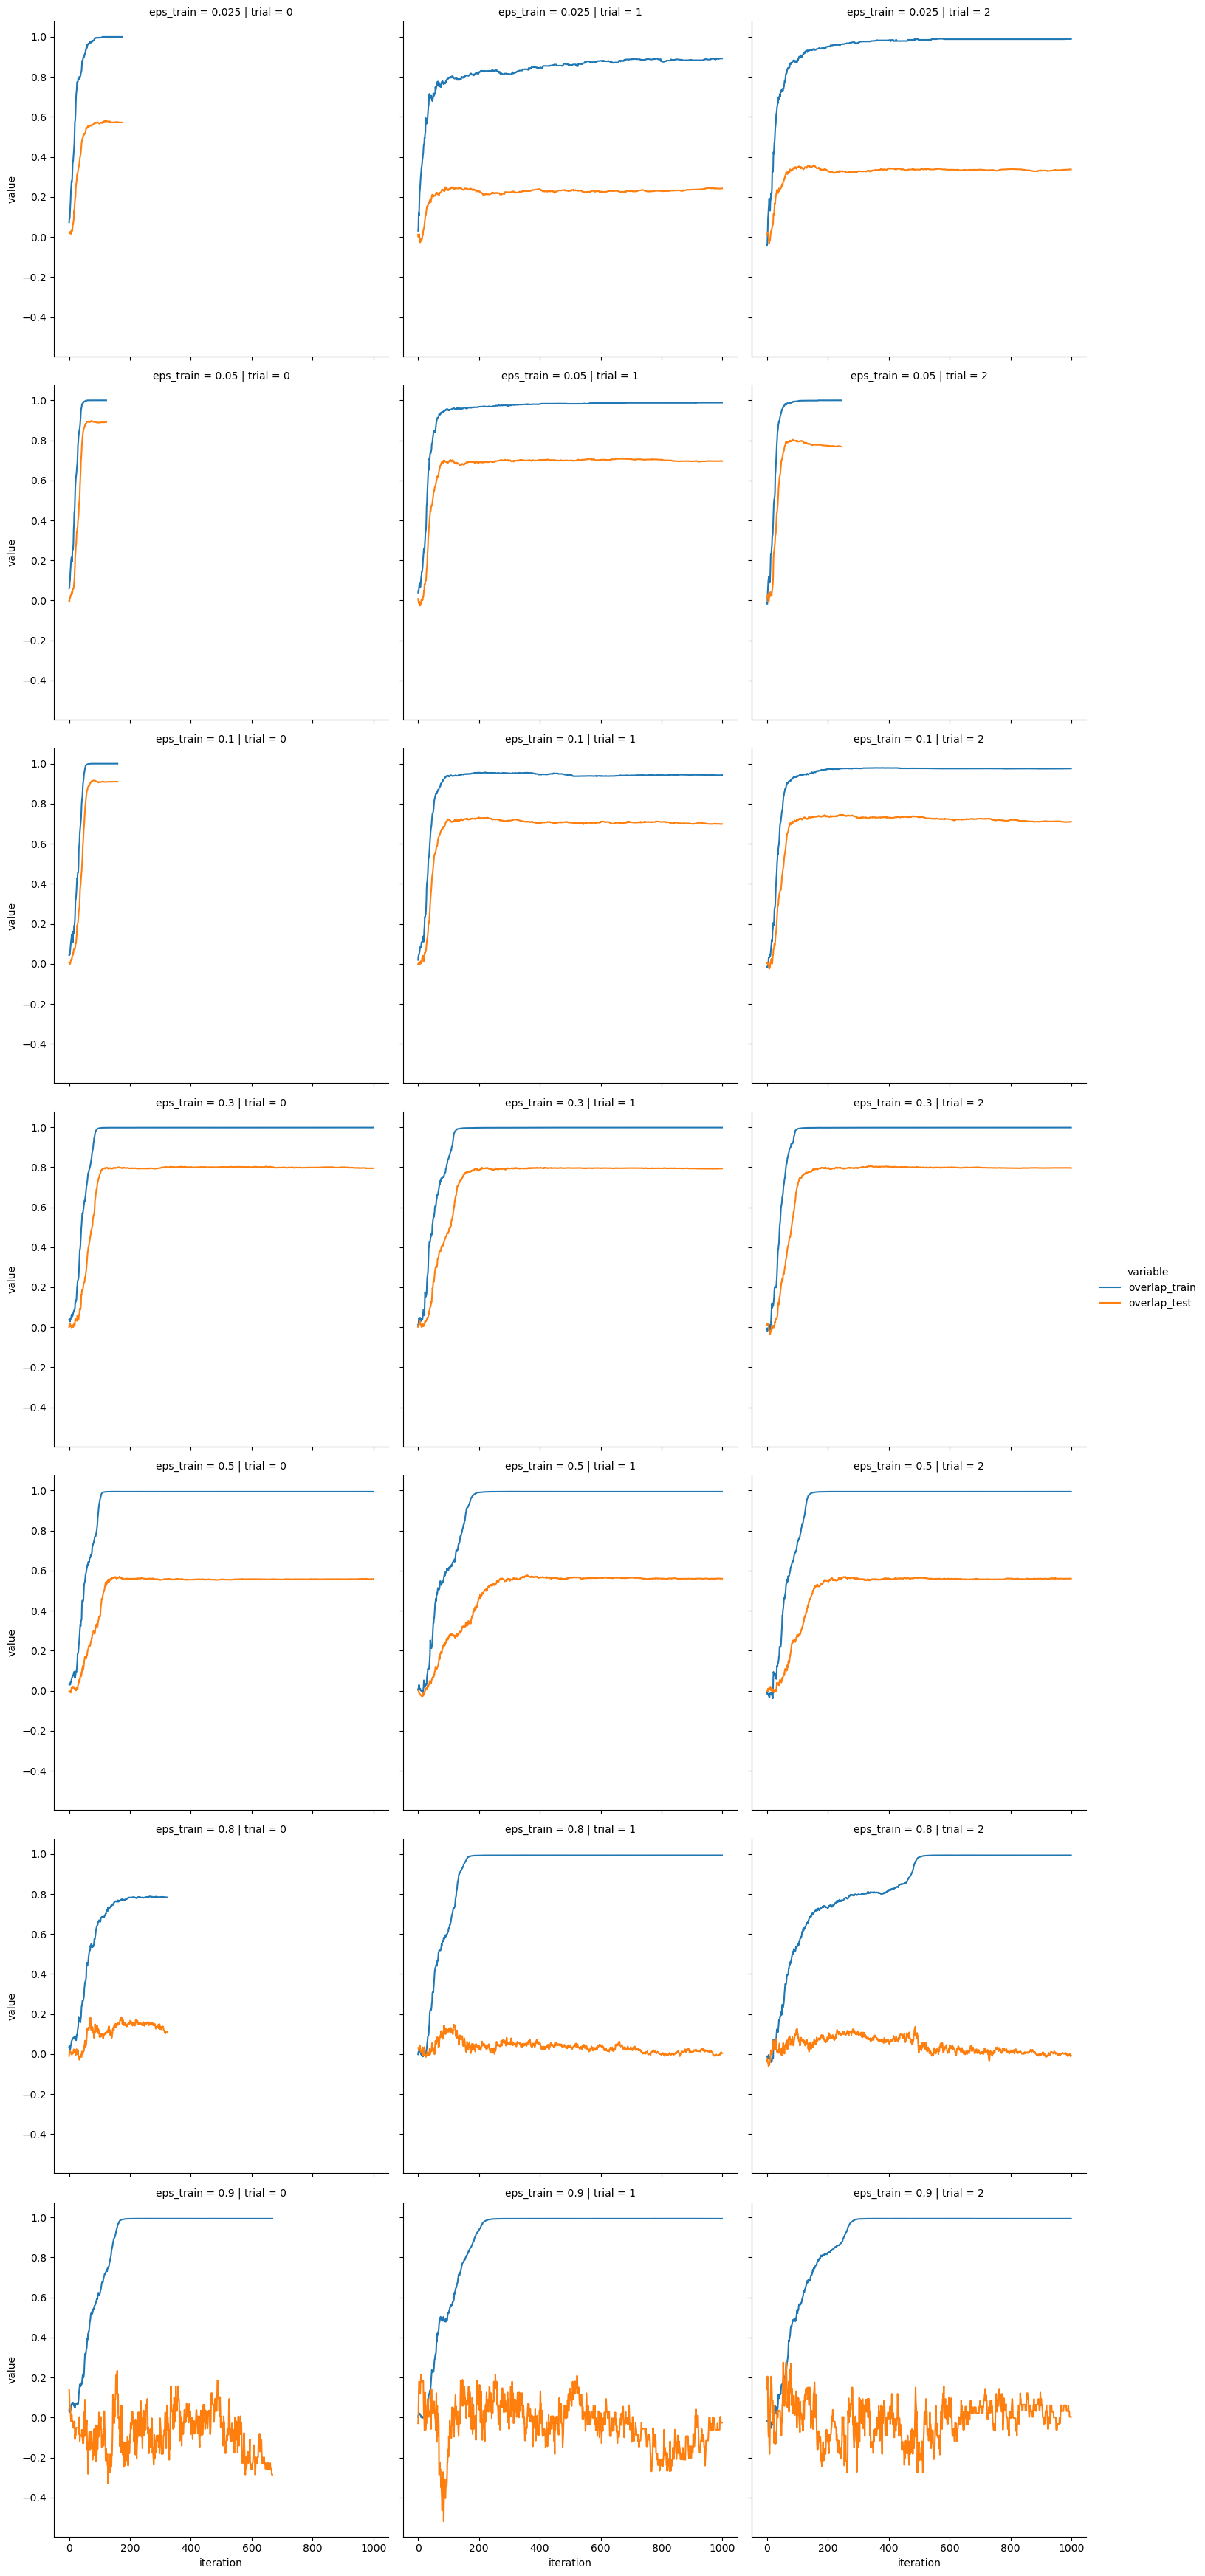

In [88]:
sns.relplot(
    data=pd.DataFrame(log).query('trial < 3')
    .assign(iteration=lambda df: df.groupby(["trial", "eps_train"]).cumcount())
    .melt(
        id_vars=["trial", "eps_train", "train_set_size", "iteration"],
        value_vars=["overlap_train", "overlap_test"],
    ),
    x="iteration",
    y="value",
    hue="variable",
    row="eps_train",
    col="trial",
    kind="line",
)
